## Task 1: Sentiment Labeling

#### Sentiment labeling was performed using the VADER (Valence Aware Dictionary and sEntiment Reasoner) model from the NLTK library. VADER is a rule-based sentiment analysis tool optimized for short-form text such as emails and workplace messages. Each message body was assigned a compound sentiment score ranging from −1 to +1. Messages with compound scores ≥ 0.05 were labeled as Positive, ≤ −0.05 as Negative, and those in between as Neutral. This approach ensures consistent, transparent, and reproducible sentiment classification across the dataset.

In [8]:
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download VADER lexicon (run once)
nltk.download('vader_lexicon')

# Load dataset
df = pd.read_csv("test.csv")

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Function to assign sentiment label
def label_sentiment(text):
    scores = sia.polarity_scores(str(text))
    compound = scores['compound']
    
    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment labeling on email body
df['sentiment_label'] = df['body'].apply(label_sentiment)
df.to_csv("test_with_sentiment.csv", index=False)
# Quick validation
print(df['sentiment_label'].value_counts())
df.head()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


sentiment_label
Positive    1528
Neutral      511
Negative     152
Name: count, dtype: int64


,Subject,body,date,from,sentiment_label
0,EnronOptions Update!,EnronOptions Announcement\n\n\nWe have updated...,5/10/2010,sally.beck@enron.com,Positive
1,(No Subject),"Marc,\n\nUnfortunately, today is not going to ...",7/29/2010,eric.bass@enron.com,Positive
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",7/25/2011,sally.beck@enron.com,Neutral
3,RE: My new work email,we were thinking papasitos (we can meet somewh...,3/25/2010,johnny.palmer@enron.com,Neutral
4,Bet,Since you never gave me the $20 for the last t...,5/21/2011,lydia.delgado@enron.com,Positive


## Task 2: Exploratory Data Analysis (EDA)

## 1. Data Structure Overview

In [ ]:
import pandas as pd
# Load sentiment-labeled dataset
df = pd.read_csv("test_with_sentiment.csv")
# Basic structure
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)
# Missing values
print("\nMissing values per column:")
print(df.isnull().sum())

Dataset shape: (2191, 5)

Data types:
Subject            object
body               object
date               object
from               object
sentiment_label    object
dtype: object

Missing values per column:
Subject            0
body               0
date               0
from               0
sentiment_label    0
dtype: int64


## 2. Sentiment Distribution

sentiment_label
Positive    1528
Neutral      511
Negative     152
Name: count, dtype: int64


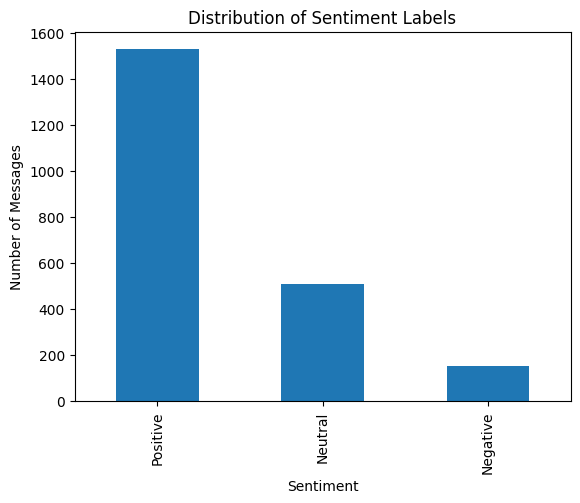

In [ ]:
import matplotlib.pyplot as plt

sentiment_counts = df['sentiment_label'].value_counts()

print(sentiment_counts)

sentiment_counts.plot(kind='bar')
plt.title("Distribution of Sentiment Labels")
plt.xlabel("Sentiment")
plt.ylabel("Number of Messages")
plt.show()


## 3. Time-Based Analysis

### Date Column

In [ ]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year_month'] = df['date'].dt.to_period('M')

### Sentiment Trends Over Time

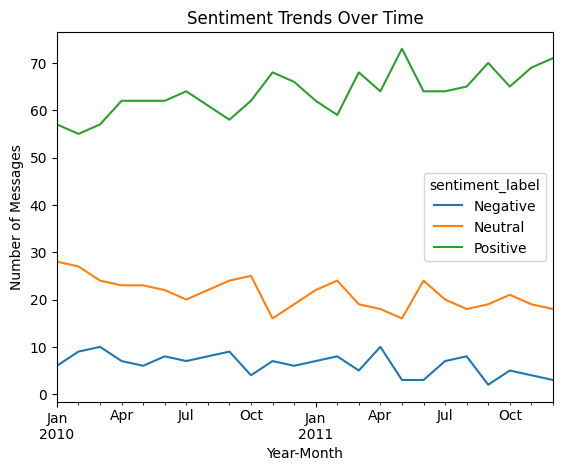

In [ ]:
sentiment_over_time = (
    df.groupby(['year_month', 'sentiment_label'])
    .size()
    .unstack(fill_value=0)
)

sentiment_over_time.plot()
plt.title("Sentiment Trends Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Number of Messages")
plt.show()


## 4. Employee-Level Activity Analysis

### Messages per Employee

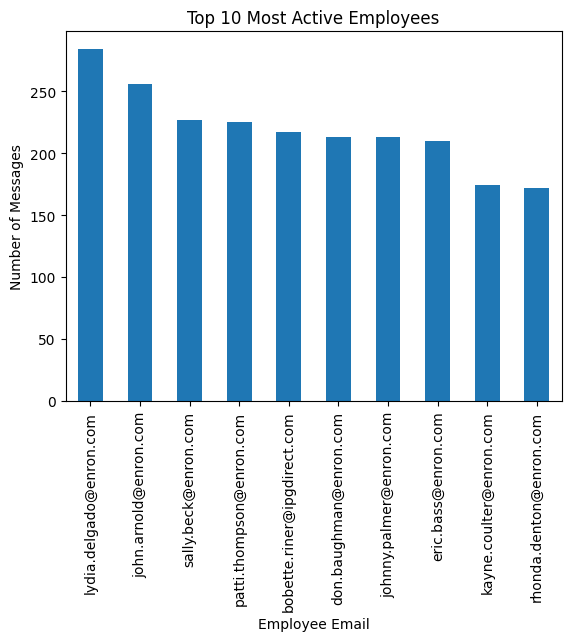

In [ ]:
employee_message_count = df['from'].value_counts().head(10)

employee_message_count.plot(kind='bar')
plt.title("Top 10 Most Active Employees")
plt.xlabel("Employee Email")
plt.ylabel("Number of Messages")
plt.show()

## 5. Negative Sentiment Concentration (Early Risk Signal)

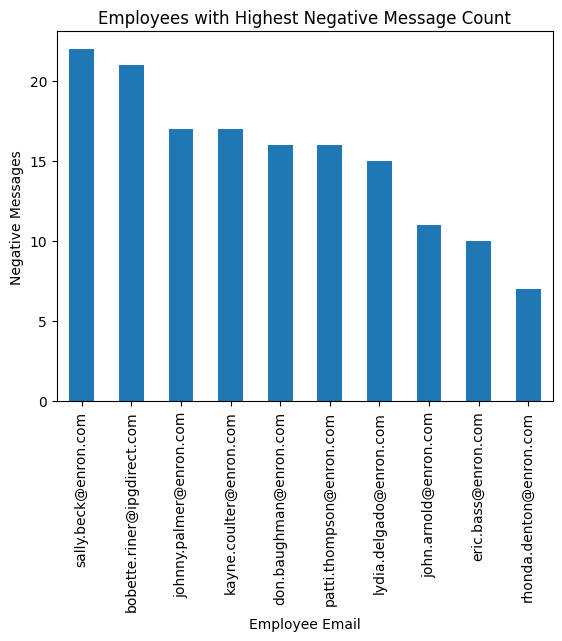

In [ ]:
negative_messages = df[df['sentiment_label'] == 'Negative']

negative_by_employee = negative_messages['from'].value_counts().head(10)

negative_by_employee.plot(kind='bar')
plt.title("Employees with Highest Negative Message Count")
plt.xlabel("Employee Email")
plt.ylabel("Negative Messages")
plt.show()

## 6. Additional Observations & Anomalies

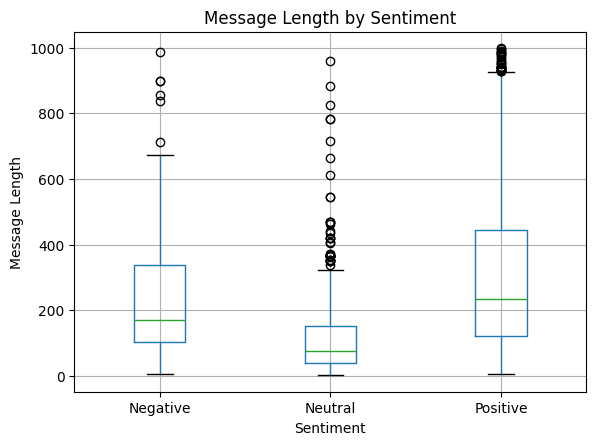

In [ ]:
df['message_length'] = df['body'].str.len()

df.boxplot(column='message_length', by='sentiment_label')
plt.title("Message Length by Sentiment")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Message Length")
plt.show()

## Task 3: Employee Score Calculation

In [ ]:
import pandas as pd

# Load dataset with sentiment labels
df = pd.read_csv("test_with_sentiment.csv")

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Extract year-month for monthly grouping
df['year_month'] = df['date'].dt.to_period('M')

# Map sentiment labels to numerical scores
sentiment_score_map = {
    "Positive": 1,
    "Negative": -1,
    "Neutral": 0
}

df['sentiment_score'] = df['sentiment_label'].map(sentiment_score_map)

# Aggregate monthly sentiment score per employee
monthly_employee_scores = (
    df.groupby(['from', 'year_month'])['sentiment_score']
      .sum()
      .reset_index()
      .rename(columns={'sentiment_score': 'monthly_sentiment_score'})
)

# Save results
monthly_employee_scores.to_csv("employee_monthly_sentiment_scores.csv", index=False)

# Preview results
monthly_employee_scores.head()


,from,year_month,monthly_sentiment_score
0,bobette.riner@ipgdirect.com,2010-01,1
1,bobette.riner@ipgdirect.com,2010-02,7
2,bobette.riner@ipgdirect.com,2010-03,6
3,bobette.riner@ipgdirect.com,2010-04,3
4,bobette.riner@ipgdirect.com,2010-05,2


In [ ]:
monthly_employee_scores.groupby('from').head(5)

,from,year_month,monthly_sentiment_score
0,bobette.riner@ipgdirect.com,2010-01,1
1,bobette.riner@ipgdirect.com,2010-02,7
2,bobette.riner@ipgdirect.com,2010-03,6
3,bobette.riner@ipgdirect.com,2010-04,3
4,bobette.riner@ipgdirect.com,2010-05,2
24,don.baughman@enron.com,2010-01,5
25,don.baughman@enron.com,2010-02,6
26,don.baughman@enron.com,2010-03,2
27,don.baughman@enron.com,2010-04,9
28,don.baughman@enron.com,2010-05,16


##### Each employee message was assigned a numerical sentiment score based on its sentiment label: +1 for positive, −1 for negative, and 0 for neutral messages. Message timestamps were converted to a year-month format to enable monthly grouping. Sentiment scores were then aggregated by employee and month using summation, ensuring that sentiment scores reset at the beginning of each new month. The resulting monthly sentiment score represents the cumulative emotional tone of an employee’s communications for that period.

In [ ]:
df[
    (df['from'] == 'bobette.riner@ipgdirect.com') &
    (df['year_month'] == '2010-02')
][['sentiment_label', 'sentiment_score']]

,sentiment_label,sentiment_score
156,Neutral,0
347,Positive,1
354,Positive,1
807,Neutral,0
828,Positive,1
1065,Positive,1
1111,Positive,1
1170,Neutral,0
1330,Negative,-1
1504,Positive,1


#### The monthly sentiment scores correctly reflect the cumulative sentiment of employee communications within each calendar month, with scores resetting at the start of each new month. This ensures accurate temporal isolation of sentiment trends and enables reliable employee ranking and risk analysis.

## Task 4: Employee Ranking

### Generate monthly rankings of employees based on their monthly sentiment scores:
1. Top 3 Positive Employees → highest monthly scores

2. Top 3 Negative Employees → lowest (most negative) monthly scores

### Sorting rules:

1. Primary: Score (descending for positive, ascending for negative)

2. Secondary: Alphabetical (employee email)

In [ ]:
import pandas as pd

# Load monthly sentiment scores
df_scores = pd.read_csv("employee_monthly_sentiment_scores.csv")
df_scores['year_month'] = pd.to_datetime(df_scores['year_month'], format='%Y-%m').dt.to_period('M')

# Initialize empty lists to store rankings
top_positive = []
top_negative = []

# Process rankings month by month
for month, group in df_scores.groupby('year_month'):
    
    # Top 3 Positive Employees
    top_pos = (
        group.sort_values(by=['monthly_sentiment_score', 'from'], ascending=[False, True])
        .head(3)
        .assign(rank='Top Positive', year_month=str(month))
    )
    
    # Top 3 Negative Employees
    top_neg = (
        group.sort_values(by=['monthly_sentiment_score', 'from'], ascending=[True, True])
        .head(3)
        .assign(rank='Top Negative', year_month=str(month))
    )
    
    top_positive.append(top_pos)
    top_negative.append(top_neg)

# Combine results
ranked_employees = pd.concat(top_positive + top_negative)

# Reorder columns for clarity
ranked_employees = ranked_employees[['year_month', 'rank', 'from', 'monthly_sentiment_score']]

# Save to CSV
ranked_employees.to_csv("employee_monthly_rankings.csv", index=False)

# Display sample
ranked_employees.head(12)


,year_month,rank,from,monthly_sentiment_score
120,2010-01,Top Positive,kayne.coulter@enron.com,13
48,2010-01,Top Positive,eric.bass@enron.com,9
144,2010-01,Top Positive,lydia.delgado@enron.com,9
73,2010-02,Top Positive,john.arnold@enron.com,11
97,2010-02,Top Positive,johnny.palmer@enron.com,10
1,2010-02,Top Positive,bobette.riner@ipgdirect.com,7
218,2010-03,Top Positive,sally.beck@enron.com,11
74,2010-03,Top Positive,john.arnold@enron.com,7
2,2010-03,Top Positive,bobette.riner@ipgdirect.com,6
27,2010-04,Top Positive,don.baughman@enron.com,9


In [ ]:
top_positive_df = ranked_employees[ranked_employees['rank'] == 'Top Positive']
print(top_positive_df.to_markdown(index=False))


| year_month   | rank         | from                        |   monthly_sentiment_score |
|:-------------|:-------------|:----------------------------|--------------------------:|
| 2010-01      | Top Positive | kayne.coulter@enron.com     |                        13 |
| 2010-01      | Top Positive | eric.bass@enron.com         |                         9 |
| 2010-01      | Top Positive | lydia.delgado@enron.com     |                         9 |
| 2010-02      | Top Positive | john.arnold@enron.com       |                        11 |
| 2010-02      | Top Positive | johnny.palmer@enron.com     |                        10 |
| 2010-02      | Top Positive | bobette.riner@ipgdirect.com |                         7 |
| 2010-03      | Top Positive | sally.beck@enron.com        |                        11 |
| 2010-03      | Top Positive | john.arnold@enron.com       |                         7 |
| 2010-03      | Top Positive | bobette.riner@ipgdirect.com |                         6 |
| 2010-04 

In [ ]:
flight_risk_df = pd.read_csv("flight_risk_employees.csv")
print(flight_risk_df.to_markdown(index=False))


| flight_risk_employee        |
|:----------------------------|
| johnny.palmer@enron.com     |
| sally.beck@enron.com        |
| bobette.riner@ipgdirect.com |
| don.baughman@enron.com      |


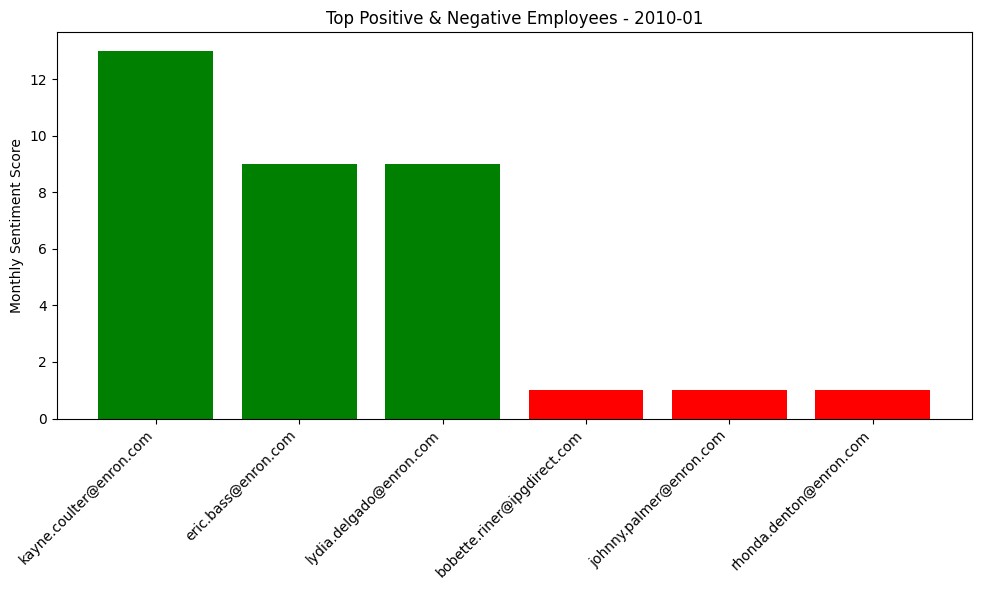

In [ ]:
import matplotlib.pyplot as plt

# plot top 3 positive vs negative for a specific month
month_to_plot = '2010-01'
plot_data = ranked_employees[ranked_employees['year_month'] == month_to_plot]

plt.figure(figsize=(10,6))
colors = plot_data['rank'].map({'Top Positive':'green', 'Top Negative':'red'})
plt.bar(plot_data['from'], plot_data['monthly_sentiment_score'], color=colors)
plt.xticks(rotation=45, ha='right')
plt.title(f"Top Positive & Negative Employees - {month_to_plot}")
plt.ylabel("Monthly Sentiment Score")
plt.tight_layout()
plt.show()


##### The monthly rankings of employees were derived directly from the monthly sentiment scores calculated in Task 3. For each calendar month, employees were sorted based on their cumulative sentiment score: the highest scores were used to identify the Top 3 Positive Employees, while the lowest (most negative) scores identified the Top 3 Negative Employees. In cases where multiple employees had the same score, alphabetical sorting by email address was applied to break ties, ensuring consistent and reproducible rankings. This approach provides a clear and objective measure of employee engagement and sentiment trends over time, highlighting individuals with consistently positive or negative communication patterns.

## Task 5: Flight Risk Identification

#### Identify employees at risk of leaving based on negative email activity:
1. Flight risk: any employee who sends 4 or more negative messages in a rolling 30-day window.

In [ ]:
import pandas as pd

# Load sentiment-labeled dataset
df = pd.read_csv("test_with_sentiment.csv")

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Filter only negative messages
neg_df = df[df['sentiment_label'] == 'Negative'].copy()

# Sort by employee and date
neg_df.sort_values(by=['from', 'date'], inplace=True)

# Initialize a column to flag flight risk
neg_df['flight_risk_flag'] = 0

# Group by employee and check rolling 30-day negative message count
flight_risk_employees = set()

for employee, group in neg_df.groupby('from'):
    dates = group['date'].tolist()
    
    # Use sliding window approach
    start_idx = 0
    for end_idx in range(len(dates)):
        # Move start index until window <= 30 days
        while (dates[end_idx] - dates[start_idx]).days > 30:
            start_idx += 1
        
        # Check if window contains 4 or more negative messages
        if end_idx - start_idx + 1 >= 4:
            flight_risk_employees.add(employee)
            break

# Convert to DataFrame for export
flight_risk_df = pd.DataFrame({'flight_risk_employee': list(flight_risk_employees)})

# Save results
flight_risk_df.to_csv("flight_risk_employees.csv", index=False)

# Preview
flight_risk_df.head()


,flight_risk_employee
0,johnny.palmer@enron.com
1,sally.beck@enron.com
2,bobette.riner@ipgdirect.com
3,don.baughman@enron.com


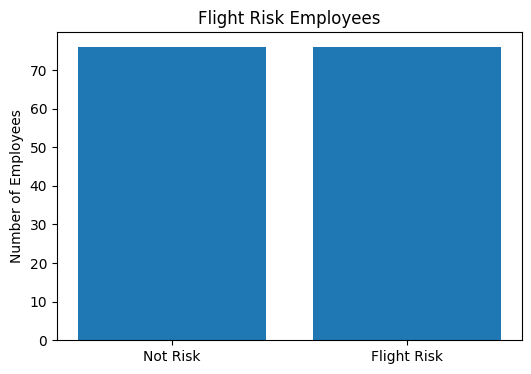

In [ ]:
import matplotlib.pyplot as plt

# Count of flight risk employees
flight_risk_counts = neg_df['from'].isin(flight_risk_employees).value_counts()

plt.figure(figsize=(6,4))
plt.bar(['Not Risk', 'Flight Risk'], flight_risk_counts)
plt.title('Flight Risk Employees')
plt.ylabel('Number of Employees')
plt.show()


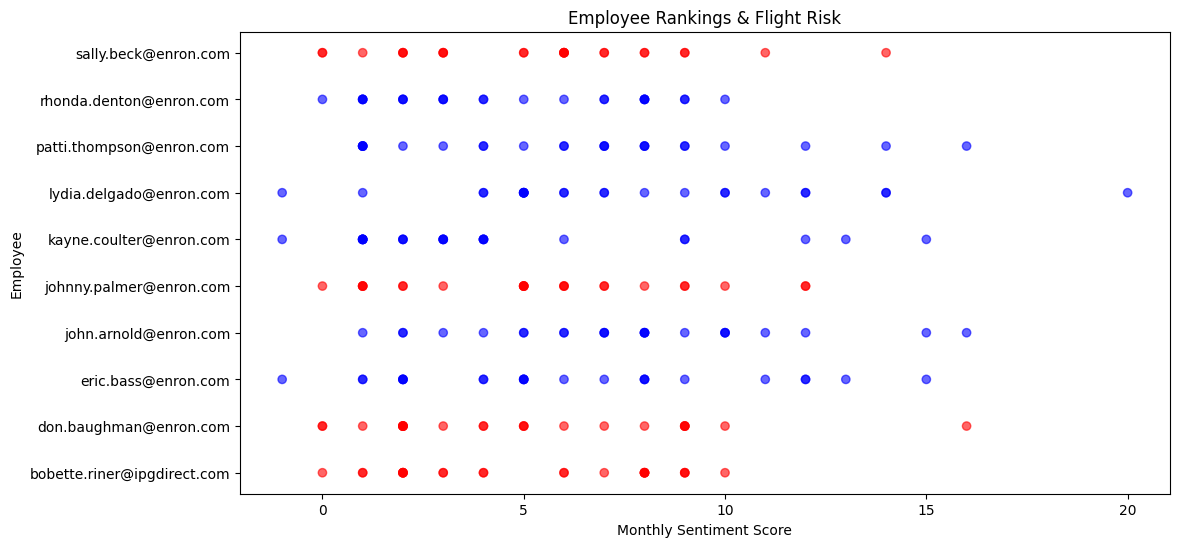

In [ ]:
# Merge flight risk info with monthly rankings
ranking_df = pd.read_csv("employee_monthly_sentiment_scores.csv")
ranking_df['is_flight_risk'] = ranking_df['from'].isin(flight_risk_employees)

plt.figure(figsize=(12,6))
plt.scatter(ranking_df['monthly_sentiment_score'], ranking_df['from'],
            c=ranking_df['is_flight_risk'].map({True:'red', False:'blue'}),
            alpha=0.6)
plt.xlabel('Monthly Sentiment Score')
plt.ylabel('Employee')
plt.title('Employee Rankings & Flight Risk')
plt.show()


##### Flight risk employees were identified by analyzing negative message patterns over rolling 30-day windows. Any employee who sent four or more negative messages within any 30-day span was flagged as a potential flight risk. This approach ensures that high-frequency negative sentiment is detected, independent of calendar months, providing a robust early-warning system for employee engagement and retention concerns.

### Task 6: Predictive Modeling – Linear Regression

#### Step 1: Load Data

##### We need two datasets:

1. test_with_sentiment.csv : contains individual emails with sentiment labels and scores

2. employee_monthly_sentiment_scores.csv : contains monthly sentiment scores per employee

In [ ]:
import pandas as pd

# Load sentiment-labeled email data
df_emails = pd.read_csv("test_with_sentiment.csv")
df_emails['date'] = pd.to_datetime(df_emails['date'], errors='coerce')
df_emails['year_month'] = df_emails['date'].dt.to_period('M')

# Load monthly sentiment scores (target variable)
df_monthly = pd.read_csv("employee_monthly_sentiment_scores.csv")


#### Step 2: Create Features

##### We want features that may influence sentiment:

1. Number of messages per month
2. Number of positive, negative, and neutral messages
3. Average message length (characters)
4. Average word count per message

In [ ]:
# Map sentiment labels to numeric scores
sentiment_score_map = {
    "Positive": 1,
    "Negative": -1,
    "Neutral": 0
}

df_emails['sentiment_score'] = df_emails['sentiment_label'].map(sentiment_score_map)


In [ ]:
# Add message length and word count
df_emails['message_length'] = df_emails['body'].str.len()
df_emails['word_count'] = df_emails['body'].str.split().apply(len)

# Aggregate features per employee-month
features = df_emails.groupby(['from', 'year_month']).agg(
    num_messages=('body', 'count'),
    num_positive=('sentiment_score', lambda x: (x==1).sum()),
    num_negative=('sentiment_score', lambda x: (x==-1).sum()),
    num_neutral=('sentiment_score', lambda x: (x==0).sum()),
    avg_message_length=('message_length', 'mean'),
    avg_word_count=('word_count', 'mean')
).reset_index()


#### Step 3: Merge Features with Target

In [ ]:
# Aggregate features per employee-month
features = df_emails.groupby(['from', 'year_month']).agg(
    num_messages=('body', 'count'),
    num_positive=('sentiment_score', lambda x: (x==1).sum()),
    num_negative=('sentiment_score', lambda x: (x==-1).sum()),
    num_neutral=('sentiment_score', lambda x: (x==0).sum()),
    avg_message_length=('body', lambda x: x.str.len().mean()),
    avg_word_count=('body', lambda x: x.str.split().apply(len).mean())
).reset_index()

# Convert 'year_month' to string so it matches df_monthly
features['year_month'] = features['year_month'].astype(str)
df_monthly['year_month'] = df_monthly['year_month'].astype(str)

# Now merge features with monthly sentiment scores
data = pd.merge(
    features, 
    df_monthly, 
    on=['from', 'year_month'], 
    how='left'
)


#### Step 4: Split Data into Train and Test

In [ ]:
# Define independent variables (features)
X = data[['num_messages', 'num_positive', 'num_negative', 'num_neutral', 
          'avg_message_length', 'avg_word_count']]

# Define dependent variable (target)
y = data['monthly_sentiment_score']


In [ ]:
from sklearn.model_selection import train_test_split

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### Step 5: Train Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize and train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Step 6: Make Predictions and Evaluate

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Predict on test set
y_pred = lr_model.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"R-squared (R²): {r2:.3f}")

Mean Squared Error (MSE): 0.000
R-squared (R²): 1.000


#### Step 7: Interpret Coefficients

In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})

print(coefficients)

              Feature   Coefficient
0        num_messages -2.481237e-16
1        num_positive  1.000000e+00
2        num_negative -1.000000e+00
3         num_neutral  8.743006e-16
4  avg_message_length  0.000000e+00
5      avg_word_count -8.326673e-16


#### Step 8: Optional Visualization

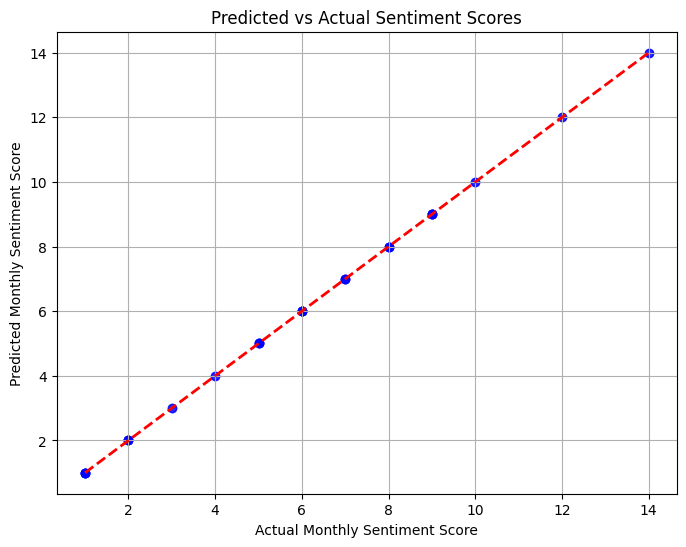

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Monthly Sentiment Score')
plt.ylabel('Predicted Monthly Sentiment Score')
plt.title('Predicted vs Actual Sentiment Scores')
plt.grid(True)
plt.show()


C:\Users\ACER\AppData\Local\Temp\ipykernel_18380\3131525533.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coefficients, palette='coolwarm')


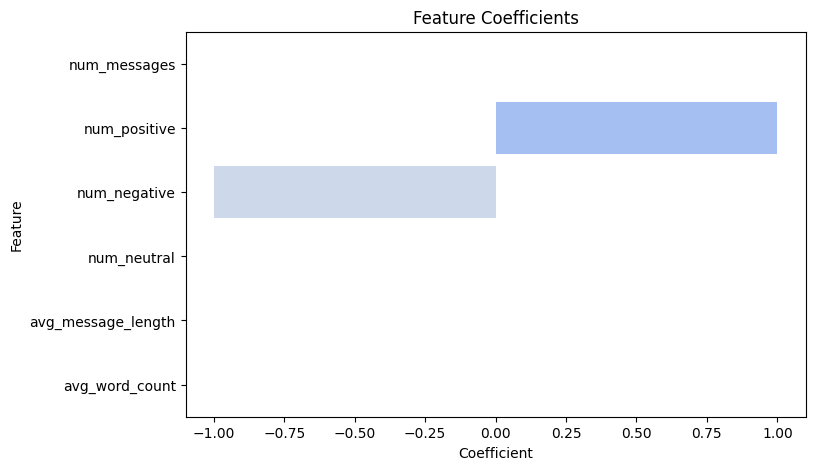

In [ ]:
import seaborn as sns
import pandas as pd

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})

plt.figure(figsize=(8,5))
sns.barplot(x='Coefficient', y='Feature', data=coefficients, palette='coolwarm')
plt.title('Feature Coefficients')
plt.show()
